# **Customer Churn Prediction Project**
1. Problem Statement

Predict whether a telecom customer will churn (leave) or not based on their usage, billing, and demographic data.
A Model that predicts if a customer will cancel a subscription?

In [1]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [2]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


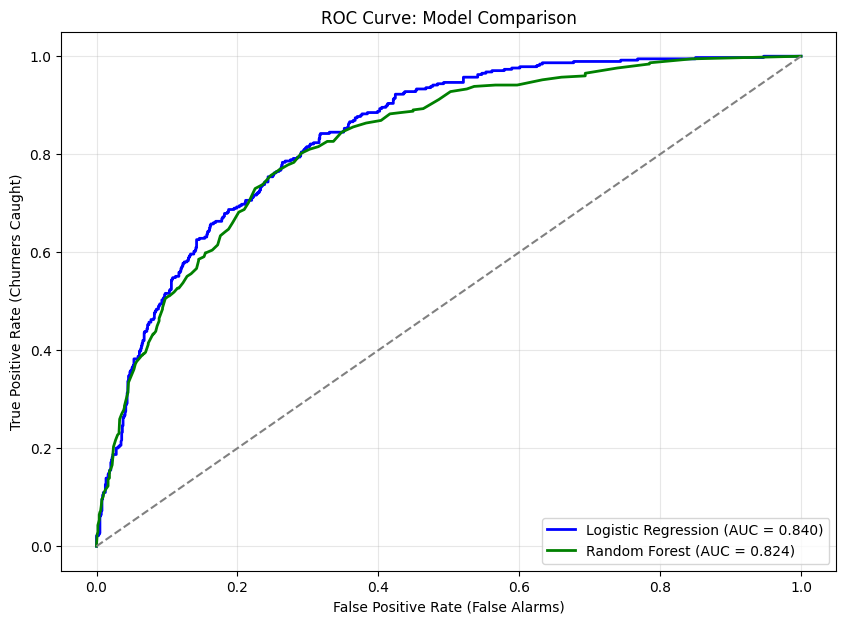

Final AUC Scores:
Logistic Regression: 0.8404
Random Forest: 0.8241


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score

# 1. DATA PREP
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. MODELS
# Baseline: Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_probs = log_model.predict_proba(X_test)[:, 1]

# Stronger: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 3. ROC & AUC CALCULATION
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)

# 4. PLOTTING THE ROC CURVE
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random Chance line
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Churners Caught)')
plt.title('ROC Curve: Model Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final AUC Scores:\nLogistic Regression: {auc_log:.4f}\nRandom Forest: {auc_rf:.4f}")

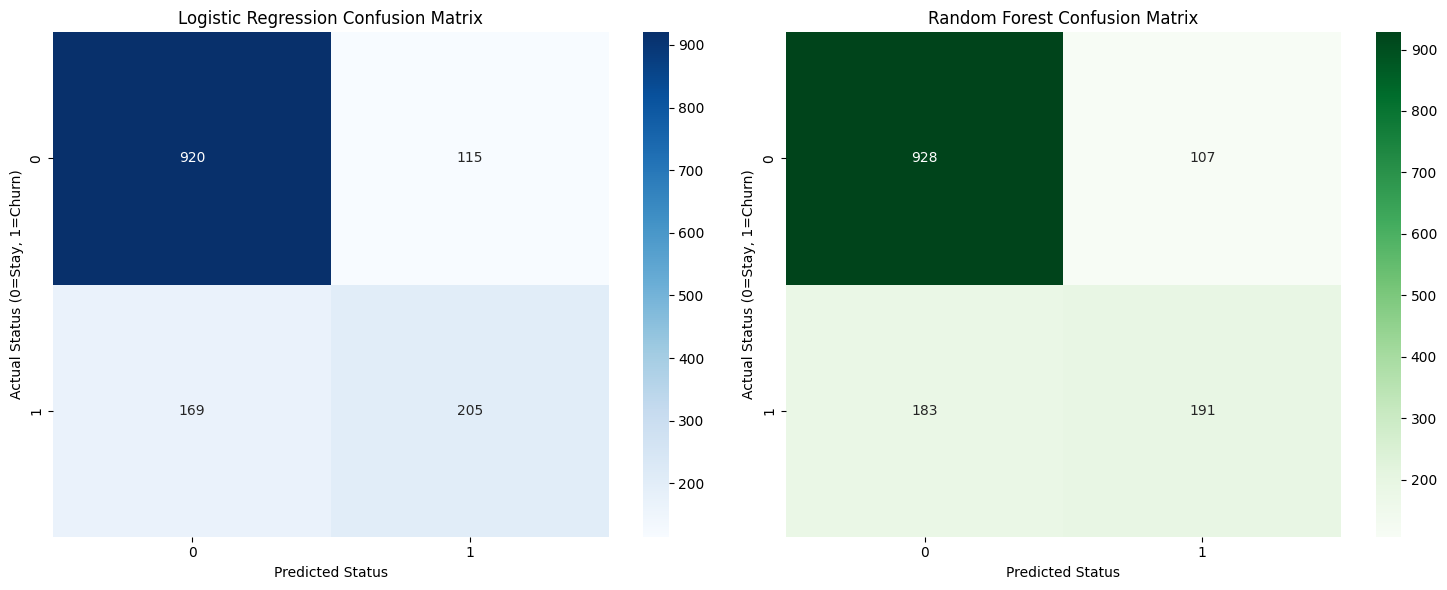

Detailed Report for Logistic Regression (The Winner):
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Get class predictions (0 or 1) instead of probabilities
log_preds = log_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Create a figure for side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_ylabel('Actual Status (0=Stay, 1=Churn)')
ax[0].set_xlabel('Predicted Status')

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_ylabel('Actual Status (0=Stay, 1=Churn)')
ax[1].set_xlabel('Predicted Status')

plt.tight_layout()
plt.show()

# Print detailed Classification Report for the "Best" model
print("Detailed Report for Logistic Regression (The Winner):")
print(classification_report(y_test, log_preds))

In [4]:
# Use the winner (Logistic Regression) to get the final list
final_probs = log_model.predict_proba(X_test)[:, 1]
final_list = pd.DataFrame({
    'Risk_Score': (final_probs * 100).round(2),
    'Prediction': ['Churn' if p > 0.5 else 'Stay' for p in final_probs]
})

# Save this to show you actually solved the problem!
final_list.to_csv('final_churn_predictions.csv', index=False)